# Librerías a importar

## Path a usar para cargar datasets y modulos

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor
from sklearn.metrics import (mean_squared_error, r2_score, mean_absolute_error, 
                             mean_absolute_percentage_error, explained_variance_score, 
                             median_absolute_error)
from sklearn.mixture import GaussianMixture
from alibi_detect.cd import KSDrift
from pathlib import Path
import sys
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline


PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))


from src.mlops.dataset import (load_data, dataset_split, clean_holiday_column, 
                           clean_functioning_day, clean_seasons, clean_mixed_type, 
                           clean_weather_features, clean_date_hour, clean_hour, 
                           clean_target, clean_date_column)

from src.mlops.preprocess import build_preprocessing_pipeline, delete_outliers

from src.mlops.features import create_time_features, encode_categorical_features

# Clases DataCleaner y FeatureEngineering

In [2]:
class DataCleaner(BaseEstimator, TransformerMixin):
    
    """
    Clase encargada de limpiar y depurar el conjunto de datos antes del modelado.

    La clase `DataCleaner` aplica de forma secuencial todas las funciones de limpieza 
    definidas en el pipeline, asegurando la consistencia, completitud y calidad del 
    dataset. Implementa la interfaz de Scikit-Learn (`BaseEstimator`, `TransformerMixin`) 
    para integrarse fácilmente en pipelines de preprocesamiento.

    Métodos
    -------
    fit(X, y=None)
        Método requerido por la API de Scikit-Learn. No realiza ajustes y retorna la propia instancia.
    transform(X)
        Aplica las distintas funciones de limpieza sobre una copia del DataFrame original, 
        incluyendo corrección de fechas, tratamiento de valores nulos, estandarización de 
        variables categóricas, limpieza de datos meteorológicos, eliminación de outliers 
        y validación de la variable objetivo.

    Parámetros
    ----------
    X : pandas.DataFrame
        Dataset original con las variables crudas antes de la limpieza.
    y : Ignorado, opcional
        Parámetro incluido por compatibilidad con la API de Scikit-Learn.

    Retorna
    -------
    pandas.DataFrame
        DataFrame completamente limpio y listo para las etapas de ingeniería de características.
    """

    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        df = clean_date_column(df)
        df = clean_holiday_column(df)
        df = clean_functioning_day(df)
        df = clean_seasons(df)
        df = clean_mixed_type(df)
        df = clean_weather_features(df)
        df = clean_target(df)
        df = clean_date_hour(df)
        df = delete_outliers(df)
        df = clean_hour(df)
        return df
    

class FeatureEngineering(BaseEstimator, TransformerMixin):
    
    """
    Clase encargada de generar características temporales a partir de la columna de fecha.

    La clase `FeatureEngineering` implementa la lógica de creación de variables derivadas 
    del tiempo mediante la función `create_time_features`. Agrega columnas como año, mes, 
    día de la semana, día del año y sus representaciones cíclicas para capturar patrones 
    temporales relevantes en el modelo.

    Métodos
    -------
    fit(X, y=None)
        Método requerido por la API de Scikit-Learn. No realiza ajustes y retorna la propia instancia.
    transform(X)
        Aplica la función `create_time_features` sobre una copia del DataFrame para generar 
        las nuevas variables temporales.

    Parámetros
    ----------
    X : pandas.DataFrame
        Dataset limpio previo a la generación de características.
    y : Ignorado, opcional
        Parámetro incluido por compatibilidad con la API de Scikit-Learn.

    Retorna
    -------
    pandas.DataFrame
        DataFrame enriquecido con variables temporales y codificaciones cíclicas.
    """

    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        df = X.copy()
        df = create_time_features(df)
        return df

# Cargamos nuestro dataset original

In [3]:
# Cargamos el dataset sin procesar
data_path = '../data/raw/seoul_bike_sharing_modified.csv'
df = load_data(data_path)

# Aplicamos la limpieza primero con Datacleaner
cleaner = DataCleaner()
df_cleaned = cleaner.fit_transform(df)

# Luego aplicamos el feature engineering
FE = FeatureEngineering()
df_featured = FE.fit_transform(df_cleaned)

# Generamos nuestros sets de entrenamiento y test
X_train, X_test, y_train, y_test = dataset_split(
        df_featured,
        target='demanda',        
        test_size=0.3,
        random_state=42 
    )

2025-11-12 22:34:25,420 [INFO] Se cargó el siguiente dataset: seoul_bike_sharing_modified.csv ✅
2025-11-12 22:34:25,421 [INFO] Dimensiones del dataset cargado: 8935 files y 15 columnas
/home/delbs/MLOps_Project/MLOps-entregas/src/mlops/dataset.py:518: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f"{col}"] = df[f"{col}"].fillna(method= 'ffill')
/home/delbs/MLOps_Project/MLOps-entregas/src/mlops/dataset.py:519: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[f"{col}"] = df[f"{col}"].fillna(method= 'bfill')
2025-11-12 22:34:25,496 [INFO] ✅ Se cargaron los features temporales correctamente.
2025-11-12 22:34:25,504 [INFO] Se llevó a cabo el split: Train=5154 | Test=2209 | Target=demanda | ✅


# Limpiamos, procesamos y creamos features a nuestro dataset

In [4]:
# Features numericos y categoricos

numerical_features_to_use = [
        'hour', "temperature(°c)", "humidity(%)", "wind_speed_(m/s)",
        "visibility_(10m)", "dew_point_temperature(°c)", "solar_radiation_(mj/m2)",
        "rainfall(mm)", "snowfall_(cm)", "year", "month", "day_of_week", "day_of_year",
        "month_sin", "month_cos", "day_of_week_sin", "day_of_week_cos", "hour_sin", "hour_cos"
    ]

categorical_features_to_use = ["seasons", "holiday", "functioning_day"]


# Pippeline
preprocessor = build_preprocessing_pipeline(
    categorical_features=categorical_features_to_use, 
    numerical_features=numerical_features_to_use
)

#  Modelo a probar
xgboost_regressor = XGBRegressor(
    test_size=0.3,
    colsample_bytree=0.8,
    n_estimators=2000,
    random_state=42,
    learning_rate=0.1,
    subsample=0.8
    )

# Instanciamos la pipeline completa
model_pipeline = Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("regressor", xgboost_regressor),
        ]
    )

# Entrenamos el modelo
model_pipeline.fit(X_train, y_train)

# Generamos las predicciones
y_pred = model_pipeline.predict(X_test)

# Guaradamos las metricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
evs = explained_variance_score(y_test, y_pred)
medae = median_absolute_error(y_test, y_pred)
mbe = np.mean(y_pred - y_test)

metrics_dict = {
                "rmse": rmse, "mae": mae, "mape": mape, "r2": r2,
                "explained_variance": evs, "median_ae": medae, "mean_bias_error": mbe
            }

# Mostramos las métricas
metrics_dict

2025-11-12 22:35:27,344 [INFO] Creando pipeline de pre-procesamiento
2025-11-12 22:35:27,346 [INFO] Se creo una pipeline de pre-procesamiento con 19 features numericos.y 3 features categoricos.
/home/delbs/Python_Envs/MLOps_312/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [22:35:27] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "test_size" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


{'rmse': 170.35837112724067,
 'mae': 92.31986852985882,
 'mape': 1.6441641054783332e+16,
 'r2': 0.9190327980708456,
 'explained_variance': 0.9190374978504611,
 'median_ae': 47.02363586425781,
 'mean_bias_error': -1.2979192090566043}

# Generamos data sintética para simular drift

In [5]:
mean_shift = 0.05

gmm = GaussianMixture(n_components=5, random_state=42).fit(df_featured['dew_point_temperature(°c)'].to_numpy().reshape(-1,1))

print("Medias originales: \n", gmm.means_)


modified_means = gmm.means_.copy()
modified_means[0] *= (1 + mean_shift)
modified_means[1] *= (1 + mean_shift)
modified_means[2] *= (1 + mean_shift)
modified_means[3] *= (1 + mean_shift)
modified_means[4] *= (1 + mean_shift)

gmm.means_ = modified_means

print("\n\nMedias alteradas: \n", gmm.means_)

synthetic_data = df_featured.copy()


synthetic_data['dew_point_temperature(°c)'] = gmm.sample(int(df_featured.describe()['dew_point_temperature(°c)']['count']))[0].reshape(-1)
X_synthetic = synthetic_data[numerical_features_to_use + categorical_features_to_use]
y_syntethic = synthetic_data['demanda']

Medias originales: 
 [[ -8.38510257]
 [ 20.18918619]
 [-18.23107845]
 [ 10.28269439]
 [  0.72037241]]


Medias alteradas: 
 [[ -8.80435769]
 [ 21.1986455 ]
 [-19.14263237]
 [ 10.79682911]
 [  0.75639103]]


In [6]:
y_synthetic_pred = model_pipeline.predict(X_synthetic)

rmse = np.sqrt(mean_squared_error(y_syntethic, y_synthetic_pred))
r2 = r2_score(y_syntethic, y_synthetic_pred)
mae = mean_absolute_error(y_syntethic, y_synthetic_pred)
mape = mean_absolute_percentage_error(y_syntethic, y_synthetic_pred)
evs = explained_variance_score(y_syntethic, y_synthetic_pred)
medae = median_absolute_error(y_syntethic, y_synthetic_pred)
mbe = np.mean(y_synthetic_pred - y_syntethic)

metrics_dict = {
                "rmse": rmse, "mae": mae, "mape": mape, "r2": r2,
                "explained_variance": evs, "median_ae": medae, "mean_bias_error": mbe
            }

metrics_dict

{'rmse': 148.86139923266904,
 'mae': 94.92845172562443,
 'mape': 1.5709021277250892e+16,
 'r2': 0.9378556479579243,
 'explained_variance': 0.9378575150978306,
 'median_ae': 56.97212219238281,
 'mean_bias_error': -0.8159615521046125}

In [7]:
# Seleccionar solo columnas numéricas (excluir categóricas para KSDrift)
X_train_numeric = X_train[numerical_features_to_use]
X_synthetic_numeric = X_synthetic[numerical_features_to_use]

# Detectar drift
cd = KSDrift(X_train_numeric.to_numpy(), p_val=0.05)
drift_pred = cd.predict(X_synthetic_numeric.to_numpy())
print('Drift detectado:', drift_pred['data']['is_drift'])

Drift detectado: 1


<Axes: xlabel='dew_point_temperature(°c)', ylabel='Density'>

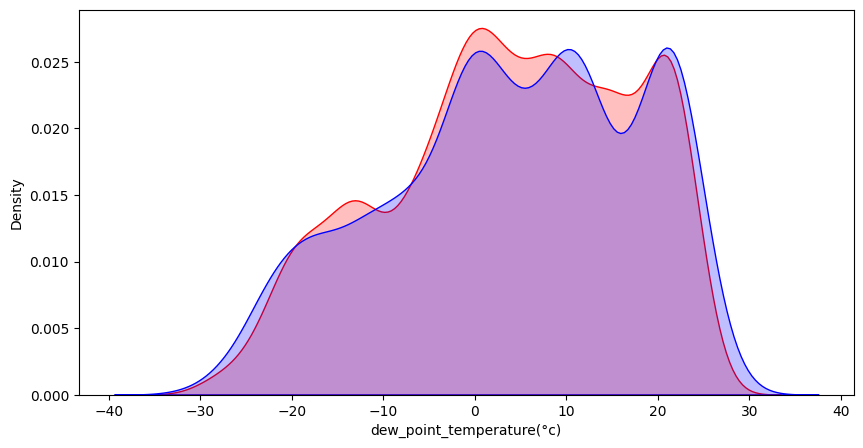

In [8]:
plt.figure(figsize=(10,5))

sns.kdeplot(df_featured['dew_point_temperature(°c)'], label="Dew point original", fill=True, color='red')
sns.kdeplot(synthetic_data['dew_point_temperature(°c)'], label='Dew point modificado', fill=True, color='blue')